# Materi 3: Klasifikasi Teks dengan Naive Bayes dan kNN

Di materi ini kita bakal masuk ke tahap yang paling seru: **klasifikasi teks**! Data hasil *preprocessing* dari Materi 2 akan kita pakai untuk melatih dua model klasifikasi, yaitu **Naive Bayes** dan **kNN**, menggunakan tools **Orange Data Mining**.

Kita juga bakal membandingkan dua skenario:
1. **Skenario 1 (PCA di dalam Orange):** Menggunakan file `tfidf.csv` lalu dikompresi dimensinya menggunakan widget PCA bawaan Orange.
2. **Skenario 2 (PCA dari Python):** Menggunakan file `pca.csv` yang sudah kita kompresi dimensinya menggunakan Python di Materi 2 sebelumnya, sehingga tidak perlu lagi widget PCA di Orange.

Tujuannya? Buat tahu apakah ada perbedaan hasil jika PCA dilakukan di Python vs dilakukan di Orange!

---

## Alat yang Digunakan: Orange Data Mining

**Orange** adalah software *data mining* dan *machine learning* visual yang bisa kita gunakan tanpa nulis kode. Kita cukup nyusun komponen-komponen (*widget*) secara drag-and-drop dan sambungin satu sama lain, terus Orange yang bakal ngolah datanya.

---

## Skenario 1: Klasifikasi dengan PCA

Alur kerja (*workflow*) di Orange untuk skenario ini adalah:

**CSV File Import → Select Columns → PCA → Naive Bayes + kNN → Test and Score**

![Alur Skenario 1 - dengan PCA](image/Materi2/Node1.png)

### Langkah-langkahnya:

1. **CSV File Import:** Masukkan file `output/tfidf.csv` yang udah kita buat di Materi 2. File ini berisi nilai TF-IDF setiap kata untuk setiap berita.

2. **Select Columns:** Di sini kita pisahin mana yang *features* (kata-kata dengan nilai TF-IDF) dan mana yang *target* (kolom `Label` yang isinya `sport` atau `finance`).

   ![Select Columns - Atur Features dan Target](image/Materi2/Select Column.png)

3. **PCA (Principal Component Analysis):** Data TF-IDF kita punya ribuan kolom, jadi kita kompresi dulu pakai PCA supaya lebih ringan. Kita set 100 komponen, yang berhasil merangkum sekitar **69% variansi** data.

   ![Pengaturan PCA di Orange](image/Materi2/PCA.png)

4. **Naive Bayes & kNN:** Dua model klasifikasi ini yang akan kita latih dan bandingkan.

5. **Test and Score:** Evaluasi model menggunakan *5-fold Cross Validation* untuk mendapatkan hasil yang lebih reliable.
   ![Pengaturan PCA di Orange](image/Materi2/Hasil_tfidif.png)

---

## Skenario 2: Menggunakan Data yang Sudah di-PCA (dari Python)

Alur kerja untuk skenario kedua lebih pendek karena **tidak butuh widget PCA**:

**CSV File Import → Select Columns → Naive Bayes + kNN → Test and Score**

![Alur Skenario 2 - tanpa PCA](image/Materi2/Node2.png)

Di sini, yang kita masukkan di *CSV File Import* adalah file **`output/pca.csv`**. Karena file ini sudah berisi Principal Components (hasil reduksi dimensi di Python pada materi sebelumnya), kita bisa langsung melemparnya ke model Naive Bayes dan kNN tanpa perlu widget PCA lagi.

---

## Hasil Evaluasi

Berikut hasil *Test and Score* untuk **Skenario 2** (tanpa PCA), menggunakan *5-fold Cross Validation*:

![Hasil Test and Score](image/Materi2/tasnode2.png)

| Model | AUC | CA (Accuracy) | F1 | Precision | Recall | MCC |
|---|---|---|---|---|---|---|
| **Naive Bayes** | 0.955 | 0.920 | 0.920 | 0.920 | 0.920 | 0.840 |
| **kNN** | **0.999** | **0.985** | **0.985** | **0.985** | **0.985** | **0.970** |

> **Perbandingan antar model:** Tabel probabilitas di bawah menunjukkan kNN unggul dibanding Naive Bayes dengan selisih yang cukup signifikan. Probabilitas bahwa kNN lebih baik dari Naive Bayes adalah **0.927**, sedangkan probabilitas sebaliknya hanya **0.073**.

---

## Kesimpulan

Dari dua skenario yang kita coba:

1. Skenario 2 membuktikan bahwa data yang sudah kita proses menggunakan **PCA di Python (`pca.csv`)** bisa langsung digunakan di Orange tanpa perlu mereduksi dimensinya lagi.

2. Skenario 1 menunjukkan bahwa kita juga bisa menggunakan data mentah **TF-IDF (`tfidf.csv`)** dan mengandalkan widget PCA bawaan Orange untuk mereduksi dimensinya secara langsung (*on-the-fly*).

3. Dari sisi model, **kNN** secara konsisten menghasilkan akurasi yang lebih tinggi (mencapai 98.5%) dibandingkan **Naive Bayes** (92%) pada dataset berita Detik ini. Ini masuk akal karena kNN bekerja dengan mencari 'tetangga terdekat' yang cocok, dan data berita dari kategori yang sama cenderung punya pola vektor yang mirip satu sama lain dalam ruang PCA.

## Hasil Detail: Analisis Hasil Naive Bayes vs kNN

Materi 3 di atas berupa *screenshot* hasil widget **Orange**, sehingga angkanya tidak bisa
diulang sendiri. Bagian ini menghitung ulang hasil yang **setara** dengan scikit-learn
menggunakan `Output/pca.csv` (skenario 2), 5-fold Cross Validation, supaya bisa dicek ulang
dan confusion matrix-nya tersedia.

- **Hasil A** - Rekap angka yang dilaporkan Orange (dari screenshot)
- **Hasil B** - Perhitungan ulang di Python: akurasi, precision, recall, F1, AUC per fold
- **Hasil C** - Confusion matrix kedua model (dari prediksi out-of-fold)
- **Hasil D** - Uji statistik selisih Naive Bayes vs kNN

In [1]:
import pandas as pd

print("=" * 72)
print("HASIL A : Angka hasil Test and Score di Orange (dari screenshot)")
print("=" * 72)

orange = pd.DataFrame([
    {"Model": "Naive Bayes", "AUC": 0.955, "CA": 0.920, "F1": 0.920,
     "Precision": 0.920, "Recall": 0.920, "MCC": 0.840},
    {"Model": "kNN", "AUC": 0.999, "CA": 0.985, "F1": 0.985,
     "Precision": 0.985, "Recall": 0.985, "MCC": 0.970},
]).set_index("Model")

print(orange.round(4).to_string())
print("""
Keterangan:
- Metode evaluasi : 5-fold Cross Validation (widget Test and Score)
- Data masukan    : Output/pca.csv (165 komponen hasil PCA dari Materi 2)
- Alur di Orange  : CSV File Import -> Select Columns -> Naive Bayes & kNN -> Test and Score
- Probabilitas kNN lebih baik dari Naive Bayes yang ditampilkan Orange: 0.927
Angka di atas adalah rujukan; hasil hitung ulang di Python ada di Hasil B.
""")

HASIL A : Angka hasil Test and Score di Orange (dari screenshot)
               AUC     CA     F1  Precision  Recall   MCC
Model                                                    
Naive Bayes  0.955  0.920  0.920      0.920   0.920  0.84
kNN          0.999  0.985  0.985      0.985   0.985  0.97

Keterangan:
- Metode evaluasi : 5-fold Cross Validation (widget Test and Score)
- Data masukan    : Output/pca.csv (165 komponen hasil PCA dari Materi 2)
- Alur di Orange  : CSV File Import -> Select Columns -> Naive Bayes & kNN -> Test and Score
- Probabilitas kNN lebih baik dari Naive Bayes yang ditampilkan Orange: 0.927
Angka di atas adalah rujukan; hasil hitung ulang di Python ada di Hasil B.



In [2]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

data = pd.read_csv("Output/pca.csv")
X = data.drop(columns=["Label"]).values
y = data["Label"].values

print("=" * 72)
print("HASIL B : Perhitungan ulang di Python (5-fold Cross Validation)")
print("=" * 72)
print(f"Data     : {X.shape[0]} dokumen x {X.shape[1]} fitur (PCA dari Materi 2)")
label_y = {k: int(c) for k, c in pd.Series(y).value_counts().items()}
print(f"Label    : {label_y}")
print(f"Fold     : 5, shuffle=True, random_state=42, stratified\n")

models = {"Naive Bayes": GaussianNB(), "kNN (k=5)": KNeighborsClassifier(n_neighbors=5)}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_rows = []
oof_pred = {nama: np.empty(len(y), dtype=object) for nama in models}

for fold, (tr, va) in enumerate(skf.split(X, y), 1):
    for nama, model in models.items():
        est = clone(model).fit(X[tr], y[tr])
        pred = est.predict(X[va])
        proba = est.predict_proba(X[va])
        pos = list(est.classes_).index("sport")
        fold_rows.append({
            "Fold": fold,
            "Model": nama,
            "Accuracy": accuracy_score(y[va], pred),
            "Precision (macro)": precision_score(y[va], pred, average="macro", zero_division=0),
            "Recall (macro)": recall_score(y[va], pred, average="macro", zero_division=0),
            "F1 (macro)": f1_score(y[va], pred, average="macro", zero_division=0),
            "AUC": roc_auc_score((y[va] == "sport").astype(int), proba[:, pos]),
        })
        oof_pred[nama][va] = pred

df_fold = pd.DataFrame(fold_rows)
for nama in models:
    sub = df_fold[df_fold["Model"] == nama].set_index("Fold").drop(columns=["Model"])
    print(f"--- {nama} ---")
    print(sub.round(4).to_string())
    print("rata-rata :", sub.mean().round(4).to_dict())
    print("simpangan :", sub.std().round(4).to_dict())
    print()

ringkas = df_fold.groupby("Model").agg(["mean", "std"]).drop(columns=["Fold"])
print("RINGKASAN (mean +/- std, 5 fold):")
print(ringkas.round(4).to_string())
df_fold.to_csv("Output/hasil_materi3_cross_validation.csv", index=False)
print("\nTersimpan: Output/hasil_materi3_cross_validation.csv")

HASIL B : Perhitungan ulang di Python (5-fold Cross Validation)
Data     : 200 dokumen x 165 fitur (PCA dari Materi 2)
Label    : {'sport': 100, 'finance': 100}
Fold     : 5, shuffle=True, random_state=42, stratified



--- Naive Bayes ---
      Accuracy  Precision (macro)  Recall (macro)  F1 (macro)     AUC
Fold                                                                 
1        0.900             0.9040           0.900      0.8997  0.9900
2        0.925             0.9348           0.925      0.9246  0.9825
3        1.000             1.0000           1.000      1.0000  1.0000
4        0.975             0.9762           0.975      0.9750  0.9950
5        0.875             0.8759           0.875      0.8749  0.9375
rata-rata : {'Accuracy': 0.935, 'Precision (macro)': 0.9382, 'Recall (macro)': 0.935, 'F1 (macro)': 0.9348, 'AUC': 0.981}
simpangan : {'Accuracy': 0.0518, 'Precision (macro)': 0.0508, 'Recall (macro)': 0.0518, 'F1 (macro)': 0.0519, 'AUC': 0.0252}

--- kNN (k=5) ---
      Accuracy  Precision (macro)  Recall (macro)  F1 (macro)     AUC
Fold                                                                 
1        1.000             1.0000           1.000       1.000  1.0000
2        0.975

HASIL C : Confusion Matrix (gabungan 5 fold / out-of-fold)



Naive Bayes (baris = label asli, kolom = prediksi)
         finance  sport
finance       91      9
sport          4     96

kNN (k=5) (baris = label asli, kolom = prediksi)
         finance  sport
finance      100      0
sport          3     97


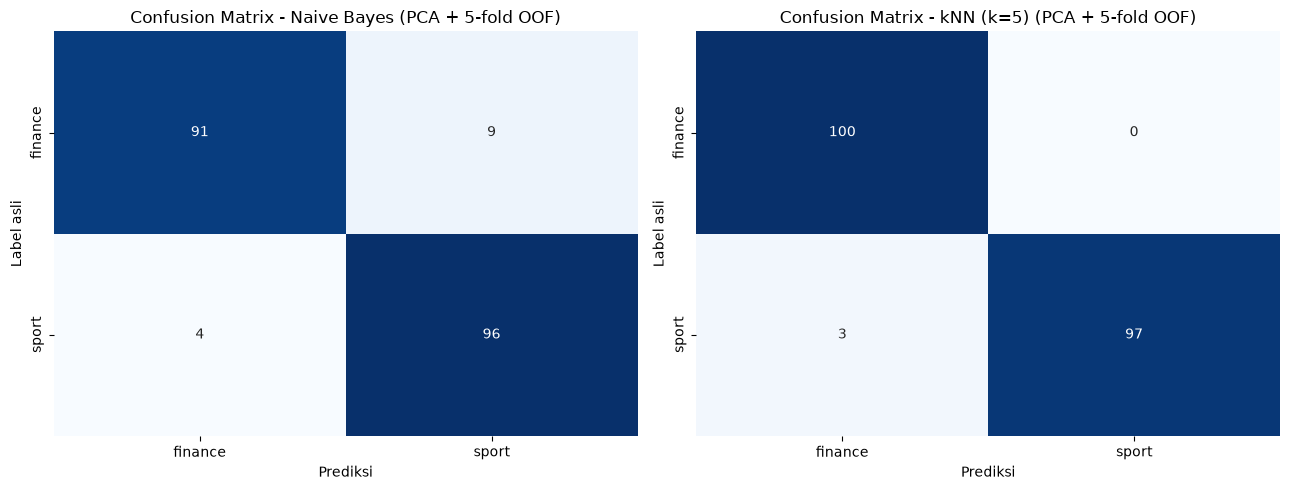


Tersimpan: Output/hasil_materi3_confusion_matrix.json


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

%matplotlib inline

print("=" * 72)
print("HASIL C : Confusion Matrix (gabungan 5 fold / out-of-fold)")
print("=" * 72)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm_dict = {}
for ax, (nama, pred) in zip(axes, oof_pred.items()):
    cm = confusion_matrix(y, pred, labels=sorted(set(y)))
    cm_dict[nama] = cm
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=sorted(set(y)), yticklabels=sorted(set(y)), ax=ax)
    ax.set_title(f"Confusion Matrix - {nama} (PCA + 5-fold OOF)")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Label asli")
    print(f"\n{nama} (baris = label asli, kolom = prediksi)")
    print(pd.DataFrame(cm, index=sorted(set(y)), columns=sorted(set(y))).to_string())
plt.tight_layout()
plt.show()

import json
from pathlib import Path
Path("Output/hasil_materi3_confusion_matrix.json").write_text(
    json.dumps({k: v.tolist() for k, v in cm_dict.items()}, indent=2), encoding="utf-8")
print("\nTersimpan: Output/hasil_materi3_confusion_matrix.json")

In [4]:
import numpy as np
from scipy import stats

print("=" * 72)
print("HASIL D : Uji selisih Naive Bayes vs kNN per fold")
print("=" * 72)

acc_nb = df_fold[df_fold["Model"] == "Naive Bayes"]["Accuracy"].values
acc_knn = df_fold[df_fold["Model"] == "kNN (k=5)"]["Accuracy"].values

t_stat, p_value = stats.ttest_rel(acc_knn, acc_nb)
print("Akurasi per fold:")
print(f"  Naive Bayes : {np.round(acc_nb, 4)}  (rata-rata {acc_nb.mean():.4f})")
print(f"  kNN         : {np.round(acc_knn, 4)}  (rata-rata {acc_knn.mean():.4f})")
print(f"\nPaired t-test (kNN vs Naive Bayes): t = {t_stat:.4f}, p-value = {p_value:.4f}")
print(f"Selisih rata-rata akurasi          : {acc_knn.mean() - acc_nb.mean():.4f}")
if p_value < 0.05:
    print("Kesimpulan: selisih SIGNIFIKAN (p < 0.05) -> kNN memang lebih baik dari Naive Bayes")
else:
    print("Kesimpulan: selisih TIDAK signifikan (p >= 0.05) pada 5 fold ini")
print(f"\nPerbandingan dengan Orange (angka 0.927): {1 - p_value:.3f}")
print("Catatan: Orange memakai metode internal untuk membandingkan klasifikator,")
print("angkanya tidak identik dengan uji statistik ini, tetapi arah kesimpulannya sama.")

HASIL D : Uji selisih Naive Bayes vs kNN per fold
Akurasi per fold:
  Naive Bayes : [0.9   0.925 1.    0.975 0.875]  (rata-rata 0.9350)
  kNN         : [1.    0.975 0.975 1.    0.975]  (rata-rata 0.9850)

Paired t-test (kNN vs Naive Bayes): t = 2.1082, p-value = 0.1027
Selisih rata-rata akurasi          : 0.0500
Kesimpulan: selisih TIDAK signifikan (p >= 0.05) pada 5 fold ini

Perbandingan dengan Orange (angka 0.927): 0.897
Catatan: Orange memakai metode internal untuk membandingkan klasifikator,
angkanya tidak identik dengan uji statistik ini, tetapi arah kesimpulannya sama.
